The following topics will be covered in this notebook:
* Venturing into Doc2Vec
* Exploring fastText
* Understanding Sent2Vec and the Universal Sentence Encoder

## Venturing into Doc2Vec

Two ways of building paragraph vectors, as follows:

1. __Distributed Memory Model of Paragraph Vectors (PV-DM):__ This is similar to the continuous bag-of-words approach we discussed regarding Word2Vec. Paragraph vectors are concatenated with the word vectors to predict the target word. Another approach is to use the average of the word and paragraph vectors to predict the target word. How are embeddings built for unseen documents after training? The model uses the built word matrix to develop embeddings for unseen documents, and these are added to the paragraph vector or document matrix. The following diagram shows how the PV-DM model is trained. In Learn Natural Language Processing (NLP), along with the word vectors of Learn, Natural, and Language, the Document vector is used to predict the next word, Processing. The model is tuned based on how it did in terms of predicting the word Processing and how it learned throughout.

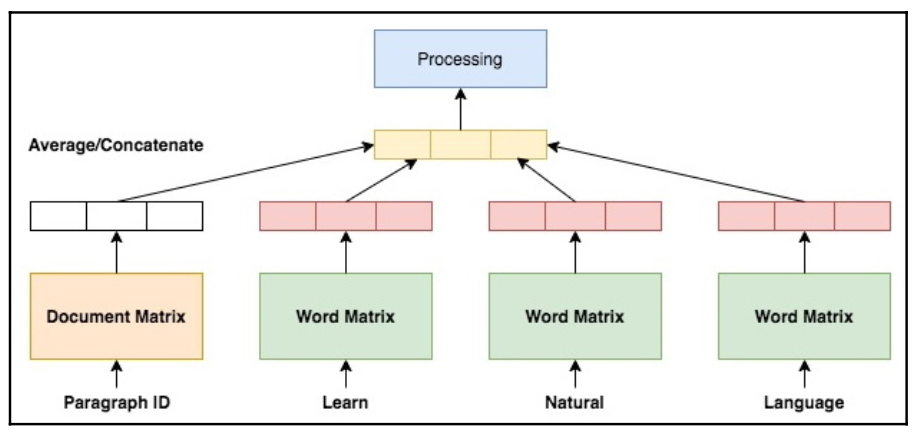

2. __Distributed Bag-of-Words Model of Paragraph Vectors (PV-DBOW):__ In this approach, word vectors aren't taken into account. Instead, the paragraph vector is used to predict randomly sampled words from the paragraph. In the process of using gradient descent and backpropagation, the paragraph vectors get adjusted and learning happens based on how good or bad they are doing in terms of making predictions. This approach is analogous to the Skip-gram approach used in Word2Vec.

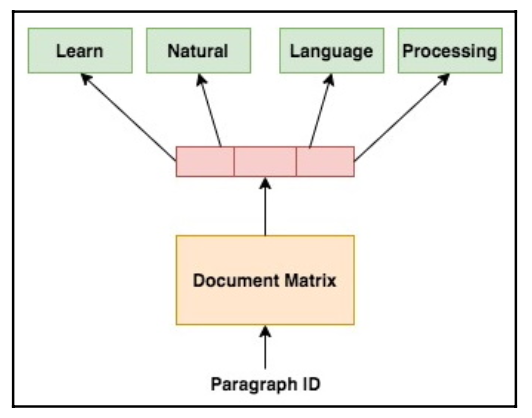


We will use the Doc2Vec module that was built as part of the Gensim library for our experimentation.

### __Building paragraph vectors using Doc2Vec__

In [1]:
from gensim.test.utils import common_texts
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [2]:
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

Lets Build Tagged Documents from the corpus as that's an expectation from the Doc2Vec model

In [3]:
documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(common_texts)]

In [17]:
documents

[TaggedDocument(words=['human', 'interface', 'computer'], tags=[0]),
 TaggedDocument(words=['survey', 'user', 'computer', 'system', 'response', 'time'], tags=[1]),
 TaggedDocument(words=['eps', 'user', 'interface', 'system'], tags=[2]),
 TaggedDocument(words=['system', 'human', 'system', 'eps'], tags=[3]),
 TaggedDocument(words=['user', 'response', 'time'], tags=[4]),
 TaggedDocument(words=['trees'], tags=[5]),
 TaggedDocument(words=['graph', 'trees'], tags=[6]),
 TaggedDocument(words=['graph', 'minors', 'trees'], tags=[7]),
 TaggedDocument(words=['graph', 'minors', 'survey'], tags=[8])]

Building a basic Doc2Vec model

In [5]:
model = Doc2Vec(documents, vector_size=5, min_count=1, workers=4, epochs = 40)
model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

In [18]:
model.vector_size

5

Nos. of document vectors did we train

In [19]:
len(model.docvecs)

/var/folders/0b/ydxznqxn43d0k3zwr07rtz480000gn/T/ipykernel_10188/844496226.py:1: DeprecationWarning: Call to deprecated `docvecs` (The `docvecs` property has been renamed `dv`.).
  len(model.docvecs)


9

Details of Vocabulary information for the model

In [21]:
len(model.wv)

12

In [24]:
model.wv.key_to_index

{'system': 0,
 'graph': 1,
 'trees': 2,
 'user': 3,
 'minors': 4,
 'eps': 5,
 'time': 6,
 'response': 7,
 'survey': 8,
 'computer': 9,
 'interface': 10,
 'human': 11}

Infer a vector based on the trained Doc2Vec model

In [25]:
vector = model.infer_vector(['user', 'interface', 'for', 'computer'])
print(vector)

[-0.08448961 -0.04599321 -0.07372917 -0.03750875  0.05157948]


Building a new model changing vector size and minimum count eligibility

In [26]:
model = Doc2Vec(documents, vector_size=50, min_count=3, epochs=40)
model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

In [29]:
vector = model.infer_vector(['user', 'interface', 'for', 'computer'])
print(len(vector))
print(vector)

50
[-0.00815784 -0.00426889 -0.00675314 -0.00325607  0.00500771  0.00396916
 -0.00307449 -0.00598003  0.0028514  -0.00837473 -0.00552565 -0.00408422
  0.00849811 -0.00129991 -0.00288296 -0.00773948 -0.00898697 -0.00436126
 -0.00828322  0.00405288  0.0024586  -0.00475123 -0.00188748  0.00581995
 -0.00058355  0.00682184 -0.00290758 -0.00338038 -0.00713871  0.00097326
  0.00945616  0.00144652 -0.00852613  0.00750459  0.0075959  -0.00723777
  0.00180308 -0.00690587  0.00103408  0.00172951  0.00492852  0.00352611
  0.00270299 -0.00730609  0.0093892   0.00058447  0.00771456 -0.00293852
 -0.00315211 -0.00816359]


Adding the dm_mean parameter to use sum of the context word vectors (`dm_mean=1`)

In [30]:
model = Doc2Vec(documents, vector_size=50, min_count=2, epochs=40, window=2, dm=1, dm_concat=0, dm_mean=1, alpha=0.3, min_alpha=0.05)
model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

In [32]:
vector = model.infer_vector(['user', 'interface', 'for', 'computer'])
print(vector)

[-0.32250097 -0.06803422 -0.20962864 -0.00902372 -0.12934045  0.12137731
 -0.16980837  0.17909023 -0.2703683   0.10996911  0.22999068  0.2645895
  0.12586737 -0.24876246  0.17051546 -0.3532029  -0.08884019  0.13077495
 -0.3470188  -0.03603599 -0.07020862  0.06497337 -0.17286438  0.17168747
 -0.04547522  0.00276077 -0.21428828 -0.2899614   0.05057118 -0.18799408
  0.33788458  0.22549792 -0.35602197 -0.06910465 -0.07947901  0.173731
 -0.02379965 -0.18873599 -0.02266201 -0.01081794 -0.11940706  0.14587852
  0.00621489 -0.32055837 -0.06259542  0.16764915  0.19329052 -0.01450425
  0.23563842 -0.18423238]


Adding the dm_mean parameter to use mean of the context word vectors (`dm_mean=0`)

In [33]:
model = Doc2Vec(documents, vector_size=50, min_count=2, epochs=40, window=2, dm=1, dm_concat=0, dm_mean=0, alpha=0.3, min_alpha=0.05)
model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

In [34]:
vector = model.infer_vector(['user', 'interface', 'for', 'computer'])
print(vector)

[-0.32250097 -0.06803422 -0.20962864 -0.00902372 -0.12934045  0.12137731
 -0.16980837  0.17909023 -0.2703683   0.10996911  0.22999068  0.2645895
  0.12586737 -0.24876246  0.17051546 -0.3532029  -0.08884019  0.13077495
 -0.3470188  -0.03603599 -0.07020862  0.06497337 -0.17286438  0.17168747
 -0.04547522  0.00276077 -0.21428828 -0.2899614   0.05057118 -0.18799408
  0.33788458  0.22549792 -0.35602197 -0.06910465 -0.07947901  0.173731
 -0.02379965 -0.18873599 -0.02266201 -0.01081794 -0.11940706  0.14587852
  0.00621489 -0.32055837 -0.06259542  0.16764915  0.19329052 -0.01450425
  0.23563842 -0.18423238]


In [35]:
model.wv.key_to_index

{'system': 0,
 'graph': 1,
 'trees': 2,
 'user': 3,
 'minors': 4,
 'eps': 5,
 'time': 6,
 'response': 7,
 'survey': 8,
 'computer': 9,
 'interface': 10,
 'human': 11}

In [37]:
len(model.wv)

12